### Try-It Activity 22.2: Sequential Data Models with Keras [2:00:00]

This try-it focuses on using `keras` to build models on sequential data.  This could either be sequential numeric data *or* you can consider text as sequential data.  `keras` contains both preprocessing tools similar to that of the `ImageDataGenerator` for time series and text data.  There are also various layer architectures to choose from including the `LSTM`, `GRU`, and even the `Conv1D`.  Below, you are to select a time series dataset using the `pandas.datareader` functionality or locate a text dataset from an external source to build the network.

#### Option 1: Time Series

Use `pandas.datareader` to locate a ticker and be sure to format the data correctly.  Here, the idea is that the last few days of pricing data could be used to predict the following days price.  Note that you do not want to use the entire series, instead simply the previous few time steps.  `keras` has a utility for taking a typical time series dataset and converting it into stacks of *lags* or previous days data (docs [here](https://keras.io/api/preprocessing/timeseries/)).  You are to load the data and use the preprocessor to present the data to the network.  Your network architecture should use any of the sequential architectures to perform a binary classification problem to predict whether the ticker will go up or down on a given day.  


**Note**: The sequential architecture is meant to refer to the hidden layers rather than the `Sequential` model object in `keras`.

Potential Sequential Hidden Layers:

- `SimpleRNN`
- `LSTM`
- `GRU`
- `Conv1D`

In [2]:
!pip install pandas_datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 4.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas_datareader]pandas_datareader]


In [13]:
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_datareader.data as pdr
from keras.layers import LSTM, GRU, Dense
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler



In [8]:
start_date = datetime(2024, 1, 1)
end_date = datetime(2025, 9, 1)

data = pdr.DataReader('TSLA', "av-daily", start=start_date, end=end_date, api_key="XQ6GIGF3QB8V8FBM")
print(data)

              open      high       low   close     volume
2024-01-02  250.08  251.2500  244.4100  248.42  104654163
2024-01-03  244.98  245.6800  236.3200  238.45  121082599
2024-01-04  239.25  242.7000  237.7300  237.93  102629283
2024-01-05  236.86  240.1196  234.9001  237.49   92240035
2024-01-08  236.14  241.2500  235.3000  240.45   85166580
...            ...       ...       ...     ...        ...
2025-08-25  338.90  349.5300  335.0300  346.60   86670037
2025-08-26  344.93  351.9000  343.7200  351.67   76651550
2025-08-27  351.94  355.3900  349.1560  349.60   65519012
2025-08-28  350.91  353.5500  340.2600  345.98   67903224
2025-08-29  347.23  348.7499  331.7000  333.87   81145660

[417 rows x 5 columns]


In [9]:
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length - 1):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)


In [10]:
seq_length = 10
X, y = create_sequences(data['open'].values, seq_length)

In [11]:
model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')


I0000 00:00:1758586146.610458 1147443 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13551 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9
/home/matt/anaconda3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
# Reshape data for (Sample, Time Steps, Features)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train the model
history = model.fit(X, y, epochs=30, validation_split=0.2, verbose=1)

Epoch 1/30


I0000 00:00:1758586360.601829 1172582 service.cc:148] XLA service 0x7ec6d8003180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758586360.601902 1172582 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti SUPER, Compute Capability 8.9
2025-09-22 17:12:40.638919: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758586360.753459 1172582 cuda_dnn.cc:529] Loaded cuDNN version 91001
I0000 00:00:1758586361.125159 1172582 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 78514.3438 - val_loss: 75392.7422
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40753.1172 - val_loss: 9254.8193
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 6753.3774 - val_loss: 5356.1987
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2844.0400 - val_loss: 1514.2839
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 842.2716 - val_loss: 1550.0037
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 607.1957 - val_loss: 379.4304
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 475.5721 - val_loss: 383.1346
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 402.1030 - val_loss: 268.9694
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 334.7036 - val_loss: 210.5831
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 266.1886 - val_loss: 280.8699
Epoch 11/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 199.7083 - val_loss: 285.7328
Epoch 12/30
11/11 ━━━━━━━━

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [16]:
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10


/home/matt/anaconda3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 90896.8594 - val_loss: 64280.0117
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 60210.6992 - val_loss: 32645.0273
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29575.5391 - val_loss: 8995.1836
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9184.1211 - val_loss: 8796.4688
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5583.8730 - val_loss: 803.5963
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1218.0323 - val_loss: 966.7970
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1230.9713 - val_loss: 513.8254
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 791.3069 - val_loss: 570.5920
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 753.5090 - val_loss: 885.8437
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 729.1879 - val_loss: 595.2628


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


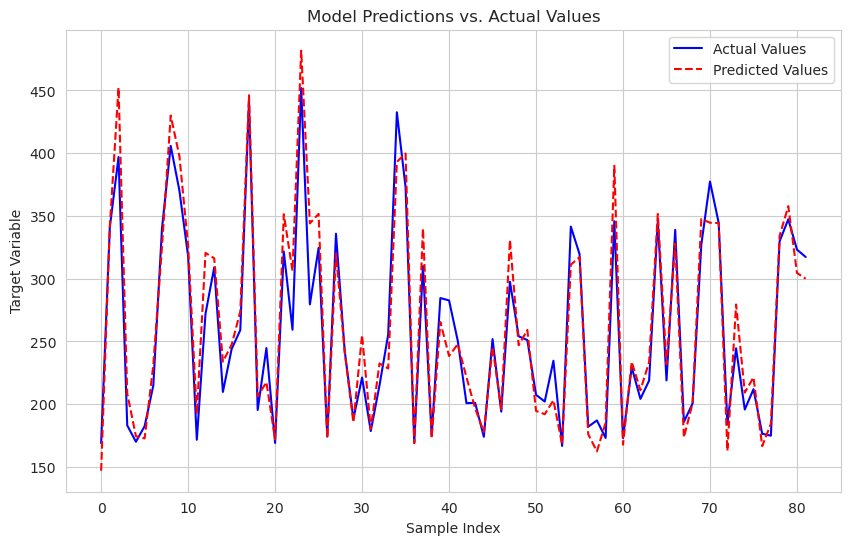

In [17]:
# Make predictions on the test data
test_predictions = model.predict(X_test)
test_predictions = test_predictions.flatten()  # Flatten the array if needed

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Values', color='blue')
plt.plot(test_predictions, label='Predicted Values', color='red', linestyle='--')
plt.title('Model Predictions vs. Actual Values')
plt.xlabel('Sample Index')
plt.ylabel('Target Variable')
plt.legend()
plt.show()

In [18]:
np.random.seed(0)
df = pd.DataFrame(np.random.randn(1000, 1), columns=['Close'])

scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)

In [19]:
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)


sequence_length = 20
X, y = create_sequences(df_scaled, sequence_length)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
model_lstm = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

model_gru = Sequential([
    GRU(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])
model_gru.compile(optimizer='adam', loss='mse')
model_gru.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/10


/home/matt/anaconda3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.1686 - val_loss: 0.0311
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0297 - val_loss: 0.0310
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0294 - val_loss: 0.0309
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0287 - val_loss: 0.0308
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0293 - val_loss: 0.0309
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0303 - val_loss: 0.0307
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0290 - val_loss: 0.0309
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0276 - val_loss: 0.0307
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0266 - val_loss: 0.0305
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0296 - val_loss: 0.0306
Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0937 - val_loss: 0.0345
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0289 - val_loss: 0.0

In [22]:
lstm_loss = model_lstm.evaluate(X_test, y_test, verbose=0)
gru_loss = model_gru.evaluate(X_test, y_test, verbose=0)

print("LSTM Test Loss:", lstm_loss)
print("GRU Test Loss:", gru_loss)

LSTM Test Loss: 0.03245861828327179
GRU Test Loss: 0.032807186245918274


In [23]:
lstm_predictions = model_lstm.predict(X_test).flatten()
gru_predictions = model_gru.predict(X_test).flatten()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [24]:
lstm_predictions = scaler.inverse_transform(lstm_predictions.reshape(-1, 1)).flatten()
gru_predictions = scaler.inverse_transform(gru_predictions.reshape(-1, 1)).flatten()
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

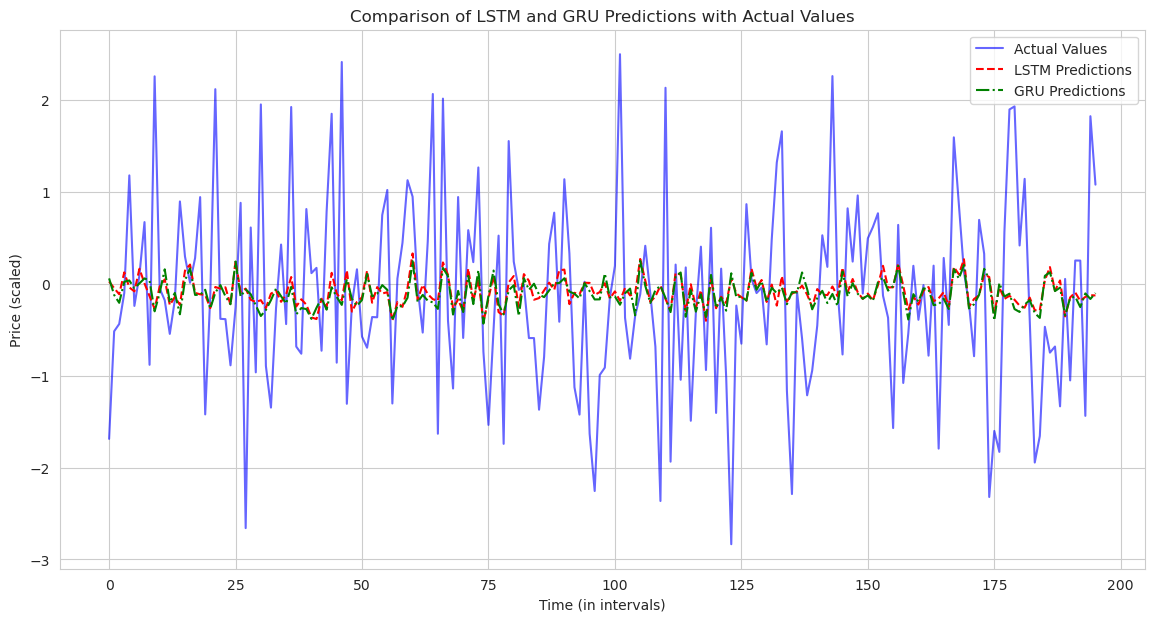

In [25]:
plt.figure(figsize=(14, 7))
plt.plot(y_test_rescaled, label='Actual Values', color='blue', alpha=0.6)
plt.plot(lstm_predictions, label='LSTM Predictions', color='red', linestyle='--')
plt.plot(gru_predictions, label='GRU Predictions', color='green', linestyle='-.')
plt.title('Comparison of LSTM and GRU Predictions with Actual Values')
plt.xlabel('Time (in intervals)')
plt.ylabel('Price (scaled)')
plt.legend()
plt.show()